# FIFA WC 2026 — EDA
**Goal:** Verify data quality before building the pipeline.

Checks:
1. results.csv — shape, nulls, date range, score distributions
2. fifa_rankings.csv — shape, nulls, coverage, team name issues
3. Join quality — how many matches can get a FIFA ranking?
4. Target distribution — win/draw/loss balance
5. Feature signal — does FIFA rank actually predict outcomes?
6. WC-specific — how do WC matches look vs friendlies?

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── adjust paths if needed ──
RESULTS_PATH  = 'data/results.csv'
RANKINGS_PATH = 'data/fifa_ranking-2026-04-01.csv'

print('Libraries loaded.')

Libraries loaded.


## 1. results.csv — Basic Health Check

In [84]:
res = pd.read_csv(RESULTS_PATH, parse_dates=['date'])

print('=== SHAPE ===')
print(f'Rows: {len(res):,}   Columns: {res.shape[1]}')

print('\n=== DTYPES ===')
print(res.dtypes)

print('\n=== FIRST 3 ROWS ===')
res.head(3)

=== SHAPE ===
Rows: 49,378   Columns: 9

=== DTYPES ===
date          datetime64[us]
home_team                str
away_team                str
home_score           float64
away_score           float64
tournament               str
city                     str
country                  str
neutral                 bool
dtype: object

=== FIRST 3 ROWS ===


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.000,0.000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.000,2.000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.000,1.000,Friendly,Glasgow,Scotland,False


In [85]:
print('=== NULLS ===')
nulls = res.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No nulls — clean!')

print('\n=== DATE RANGE ===')
print(f'Earliest : {res.date.min().date()}')
print(f'Latest   : {res.date.max().date()}')
print(f'Span     : {(res.date.max() - res.date.min()).days // 365} years')

=== NULLS ===
home_score    72
away_score    72
dtype: int64

=== DATE RANGE ===
Earliest : 1872-11-30
Latest   : 2026-06-27
Span     : 153 years


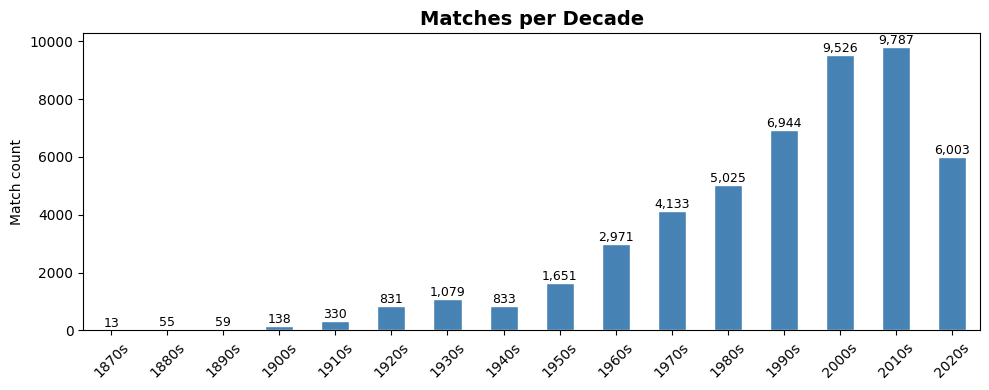


Note: Pre-2000 data is sparse and from a different era of football.
We will train on 2000+ only.


In [86]:
# Matches per decade
res['decade'] = (res['date'].dt.year // 10 * 10).astype(str) + 's'
decade_counts = res.groupby('decade').size()

fig, ax = plt.subplots(figsize=(10, 4))
decade_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Matches per Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Match count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNote: Pre-2000 data is sparse and from a different era of football.')
print('We will train on 2000+ only.')

## 2. Score Distribution & Target Variable

=== RESULT DISTRIBUTION (home team POV) ===
result
win     24163
loss    13935
draw    11208
Name: count, dtype: int64

Win%  : 49.0%
Draw% : 22.7%
Loss% : 28.3%


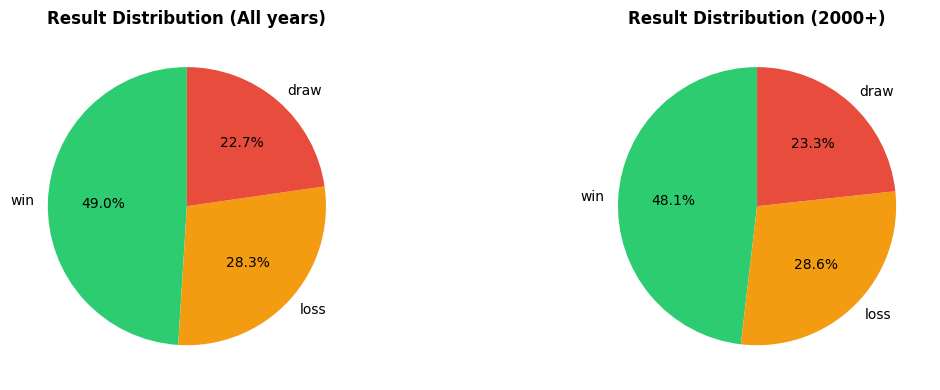


Class balance check: if win% >> loss%, home advantage is real.
For WC (neutral venues), we expect more balance.


In [87]:
# Derive result
def get_result(row):
    if pd.isna(row['home_score']) or pd.isna(row['away_score']):
        return None
    if row['home_score'] > row['away_score']:
        return 'win'
    elif row['home_score'] == row['away_score']:
        return 'draw'
    else:
        return 'loss'

res['result'] = res.apply(get_result, axis=1)

print('=== RESULT DISTRIBUTION (home team POV) ===')
rc = res['result'].value_counts()
print(rc)
print(f'\nWin%  : {rc["win"]  / rc.sum() * 100:.1f}%')
print(f'Draw% : {rc["draw"] / rc.sum() * 100:.1f}%')
print(f'Loss% : {rc["loss"] / rc.sum() * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart
axes[0].pie(rc, labels=rc.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[0].set_title('Result Distribution (All years)', fontweight='bold')

# Post-2000 only
res_modern = res[res['date'].dt.year >= 2000]
rc2 = res_modern['result'].value_counts()
axes[1].pie(rc2, labels=rc2.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1].set_title('Result Distribution (2000+)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClass balance check: if win% >> loss%, home advantage is real.')
print('For WC (neutral venues), we expect more balance.')

=== GOAL DISTRIBUTION ===
Home goals: {'count': 49306.0, 'mean': 1.76, 'std': 1.77, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 2.0, 'max': 31.0}
Away goals: {'count': 49306.0, 'mean': 1.18, 'std': 1.4, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 2.0, 'max': 21.0}


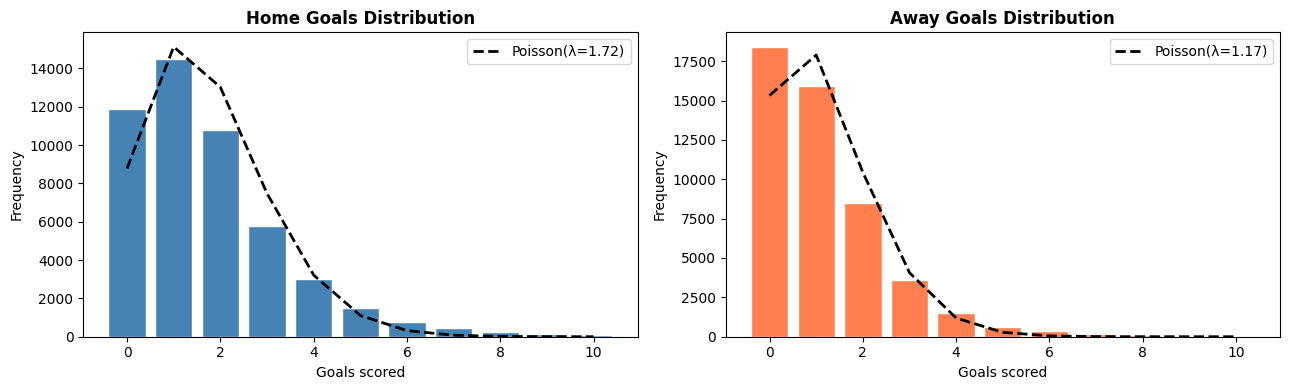


If bars follow the dashed line closely → Poisson model is valid for score prediction.
Dixon-Coles correction handles the 0-0/1-0 underestimation.


In [88]:
# Score distribution — important for Poisson model
print('=== GOAL DISTRIBUTION ===')
print('Home goals:', res['home_score'].describe().round(2).to_dict())
print('Away goals:', res['away_score'].describe().round(2).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, color in zip(
    axes,
    ['home_score', 'away_score'],
    ['Home Goals', 'Away Goals'],
    ['steelblue', 'coral']
):
    vals = res[col].dropna()
    vals = vals[vals <= 10]  # clip outliers for display
    counts = vals.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.set_xlabel('Goals scored')
    ax.set_ylabel('Frequency')
    # overlay Poisson expectation
    from scipy.stats import poisson
    mu = vals.mean()
    x = np.arange(0, 11)
    poisson_fit = poisson.pmf(x, mu) * len(vals)
    ax.plot(x, poisson_fit, 'k--', linewidth=2, label=f'Poisson(λ={mu:.2f})')
    ax.legend()

plt.tight_layout()
plt.show()

print('\nIf bars follow the dashed line closely → Poisson model is valid for score prediction.')
print('Dixon-Coles correction handles the 0-0/1-0 underestimation.')

In [89]:
# Most common scorelines
res['scoreline'] = res['home_score'].astype(str) + '-' + res['away_score'].astype(str)
print('=== TOP 15 MOST COMMON SCORELINES ===')
print(res['scoreline'].value_counts().head(15).to_string())

=== TOP 15 MOST COMMON SCORELINES ===
scoreline
1.0-0.0    5090
1.0-1.0    4893
0.0-0.0    3960
2.0-0.0    3828
2.0-1.0    3763
0.0-1.0    3450
1.0-2.0    2542
3.0-0.0    2355
0.0-2.0    2220
2.0-2.0    1937
3.0-1.0    1902
4.0-0.0    1357
1.0-3.0    1090
0.0-3.0    1079
3.0-2.0     994


## 3. Tournament Coverage

In [90]:
print('=== TOP 20 TOURNAMENTS BY MATCH COUNT ===')
tc = res['tournament'].value_counts().head(20)
print(tc.to_string())

print(f'\nTotal unique tournaments: {res["tournament"].nunique()}')

=== TOP 20 TOURNAMENTS BY MATCH COUNT ===
tournament
Friendly                                18301
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368

Total unique tournaments: 

In [91]:
# World Cup matches specifically
wc = res[res['tournament'] == 'FIFA World Cup']
print(f'=== FIFA WORLD CUP MATCHES ===')
print(f'Total WC matches in dataset : {len(wc):,}')
print(f'Date range                  : {wc.date.min().date()} → {wc.date.max().date()}')

print('\nWC Result distribution (home team POV):')
wc_rc = wc['result'].value_counts()
print(wc_rc)
print(f'Win%  : {wc_rc["win"]  / wc_rc.sum() * 100:.1f}%')
print(f'Draw% : {wc_rc["draw"] / wc_rc.sum() * 100:.1f}%')
print(f'Loss% : {wc_rc["loss"] / wc_rc.sum() * 100:.1f}%')

print('\nNote: WC matches are all neutral=True so home/away is just fixture order.')

=== FIFA WORLD CUP MATCHES ===
Total WC matches in dataset : 1,036
Date range                  : 1930-07-13 → 2026-06-27

WC Result distribution (home team POV):
result
win     439
loss    311
draw    214
Name: count, dtype: int64
Win%  : 45.5%
Draw% : 22.2%
Loss% : 32.3%

Note: WC matches are all neutral=True so home/away is just fixture order.


In [92]:
# Neutral venue breakdown
neutral_counts = res['neutral'].value_counts()
print('=== NEUTRAL VENUE BREAKDOWN ===')
print(neutral_counts)

# Home advantage: win% at home vs neutral
home_win_home    = res[res['neutral'] == False]['result'].eq('win').mean()
home_win_neutral = res[res['neutral'] == True]['result'].eq('win').mean()
print(f'\nHome team win% (non-neutral venues) : {home_win_home:.1%}')
print(f'Home team win% (neutral venues)     : {home_win_neutral:.1%}')
print('\nIf gap is large → is_neutral is a strong feature. Expected ~10pp gap.')

=== NEUTRAL VENUE BREAKDOWN ===
neutral
False    36306
True     13072
Name: count, dtype: int64

Home team win% (non-neutral venues) : 50.7%
Home team win% (neutral venues)     : 44.0%

If gap is large → is_neutral is a strong feature. Expected ~10pp gap.


## 4. FIFA Rankings — Health Check

In [93]:
rnk = pd.read_csv(RANKINGS_PATH)

# ── Hardcode correct column names (confirmed from your CSV) ──
date_col  = 'rank_date'
team_col  = 'country_full'
rank_col  = 'rank'

print('=== SHAPE ===')
print(f'Rows: {len(rnk):,}   Columns: {rnk.shape[1]}')
print('\n=== COLUMNS ===')
print(list(rnk.columns))

# Parse dates
rnk[date_col] = pd.to_datetime(rnk[date_col], dayfirst=True, errors='coerce')
rnk = rnk.dropna(subset=[date_col])

print(f'\nRanking date range  : {rnk[date_col].min().date()} → {rnk[date_col].max().date()}')
print(f'Unique rank dates   : {rnk[date_col].nunique()}')
print(f'Unique teams ranked : {rnk[team_col].nunique()}')
print(f'Nulls in rank col   : {rnk[rank_col].isnull().sum()}')

# Ranking update frequency
dates = rnk[date_col].drop_duplicates().sort_values()
gaps  = dates.diff().dt.days.dropna()
print(f'\n=== RANKING UPDATE FREQUENCY ===')
print(f'  Median gap : {gaps.median():.0f} days')
print(f'  Max gap    : {gaps.max():.0f} days')

# Sample of team names in rankings (for NAME_MAP debugging)
print(f'\n=== SAMPLE TEAM NAMES IN RANKINGS (sorted) ===')
sample_teams = sorted(rnk[team_col].unique())
print(sample_teams[:30])
print('...')
print(sample_teams[-10:])

=== SHAPE ===
Rows: 70,194   Columns: 9

=== COLUMNS ===
['Unnamed: 0', 'rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']

Ranking date range  : 1992-12-31 → 2026-04-01
Unique rank dates   : 346
Unique teams ranked : 216
Nulls in rank col   : 9

=== RANKING UPDATE FREQUENCY ===
  Median gap : 28 days
  Max gap    : 220 days

=== SAMPLE TEAM NAMES IN RANKINGS (sorted) ===
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam']
...
['Uzbekistan', 'Vanuatu', 'Venezuela', 'Vietnam', 'Wales', 'Yemen', 'Yugoslavia', 'Zaire', 'Zambia', 'Zimbabwe']


In [94]:
# rnk = pd.read_csv(RANKINGS_PATH)

# print('=== SHAPE ===')
# print(f'Rows: {len(rnk):,}   Columns: {rnk.shape[1]}')

# print('\n=== COLUMNS ===')
# print(list(rnk.columns))

# print('\n=== SAMPLE (last 5 rows = most recent) ===')
# rnk.tail(5)

In [95]:
# # Detect the date column (try common names)
# date_col = None
# for c in rnk.columns:
#     if 'date' in c.lower():
#         date_col = c
#         break

# team_col = None
# for c in rnk.columns:
#     if any(k in c.lower() for k in ['country_full', 'team_name', 'name', 'country']):
#         team_col = c
#         break

# rank_col = None
# for c in rnk.columns:
#     if any(k in c.lower() for k in ['rank_position', 'rank', 'current_rank']):
#         if 'change' not in c.lower() and 'previous' not in c.lower():
#             rank_col = c
#             break

# print(f'Detected → date: {date_col!r}  |  team: {team_col!r}  |  rank: {rank_col!r}')

# rnk[date_col] = pd.to_datetime(rnk[date_col], dayfirst=True, errors='coerce')
# rnk = rnk.dropna(subset=[date_col])

# print(f'\nRanking date range: {rnk[date_col].min().date()} → {rnk[date_col].max().date()}')
# print(f'Unique ranking snapshots (dates): {rnk[date_col].nunique()}')
# print(f'Unique teams ranked: {rnk[team_col].nunique()}')
# print(f'Nulls in rank column: {rnk[rank_col].isnull().sum()}')

In [96]:
# # Ranking update frequency
# dates = rnk[date_col].drop_duplicates().sort_values()
# gaps = dates.diff().dt.days.dropna()
# print('=== RANKING UPDATE FREQUENCY (days between snapshots) ===')
# print(f'  Median gap : {gaps.median():.0f} days')
# print(f'  Mean gap   : {gaps.mean():.0f} days')
# print(f'  Max gap    : {gaps.max():.0f} days')
# print(f'  Min gap    : {gaps.min():.0f} days')
# print('\nNote: We join rankings to matches using most recent snapshot ≤ match date.')
# print('Gaps up to ~2 months are fine — rankings do not change dramatically.')

In [97]:
# Apply name mapping so rankings team names match results.csv
NAME_MAP = {
    # Asia
    "Korea Republic":              "South Korea",
    "Korea DPR":                   "North Korea",
    "IR Iran":                     "Iran",
    "China":                       "China PR",
    "Chinese Taipei":              "Taiwan",
    "Kyrgyz Republic":             "Kyrgyzstan",
    "Brunei Darussalam":           "Brunei",

    # Europe
    "Türkiye":                     "Turkey",
    "Czechia":                     "Czech Republic",
    "Bosnia-Herzegovina":          "Bosnia and Herzegovina",

    # Africa
    "Côte d'Ivoire":               "Ivory Coast",
    "Congo DR":                    "DR Congo",
    "Cabo Verde":                  "Cape Verde",

    # Americas
    "USA":                         "United States",

    # Caribbean
    "St. Kitts and Nevis":         "Saint Kitts and Nevis",
    "St. Lucia":                   "Saint Lucia",
    "St. Vincent / Grenadines":    "Saint Vincent and the Grenadines",
}

rnk[team_col] = rnk[team_col].map(lambda n: NAME_MAP.get(n, n))

print(f'Name mapping applied. Unique teams after mapping: {rnk[team_col].nunique()}')

# Verify a few key ones
for rankings_name, results_name in [("USA", "United States"), ("Korea Republic", "South Korea"), ("IR Iran", "Iran")]:
    found = results_name in rnk[team_col].values
    print(f'  {rankings_name} → {results_name} : {"✅ mapped" if found else "❌ still missing"}')

Name mapping applied. Unique teams after mapping: 216
  USA → United States : ✅ mapped
  Korea Republic → South Korea : ✅ mapped
  IR Iran → Iran : ✅ mapped


## 5. Join Quality — How Many Matches Get a FIFA Ranking?

In [98]:
import bisect

# ── Build rank lookup: team_name → (sorted dates list, ranks list) ──
rank_lookup = {}
for team, grp in rnk.groupby(team_col):
    grp_sorted = grp.sort_values(date_col)
    rank_lookup[team] = (
        list(grp_sorted[date_col]),   # datetime objects
        list(grp_sorted[rank_col])
    )

# DEBUG: confirm a known team works
test_team = 'Germany'
test_date = pd.Timestamp('2018-06-01')
if test_team in rank_lookup:
    dates_list, ranks_list = rank_lookup[test_team]
    idx = bisect.bisect_right(dates_list, test_date) - 1
    print(f'DEBUG: {test_team} rank on {test_date.date()} → {ranks_list[idx] if idx >= 0 else "NOT FOUND"}')
    print(f'DEBUG: type of dates_list[0] = {type(dates_list[0])}')
    print(f'DEBUG: type of test_date     = {type(test_date)}')
else:
    print(f'DEBUG: "{test_team}" NOT in rank_lookup — name mismatch!')
    # Show what Germany-like names exist
    matches = [t for t in rank_lookup if 'erman' in t]
    print(f'       Similar names: {matches}')

# ── Lookup function ──
def get_rank(team, match_date):
    if team not in rank_lookup:
        return None
    dates_list, ranks_list = rank_lookup[team]
    # ensure match_date is Timestamp for bisect comparison
    if not isinstance(match_date, pd.Timestamp):
        match_date = pd.Timestamp(match_date)
    idx = bisect.bisect_right(dates_list, match_date) - 1
    if idx < 0:
        return None
    return ranks_list[idx]

# ── Run on modern matches ──
modern = res[res['date'].dt.year >= 2000].copy()
modern['home_rank'] = modern.apply(lambda r: get_rank(r['home_team'], r['date']), axis=1)
modern['away_rank'] = modern.apply(lambda r: get_rank(r['away_team'], r['date']), axis=1)
modern['both_ranked'] = modern['home_rank'].notna() & modern['away_rank'].notna()

total   = len(modern)
both_ok = modern['both_ranked'].sum()

print(f'\n=== JOIN QUALITY (matches from 2000+) ===')
print(f'Total modern matches    : {total:,}')
print(f'Both teams have ranking : {both_ok:,}  ({both_ok/total:.1%})')
print(f'Home ranking missing    : {modern["home_rank"].isna().sum():,}')
print(f'Away ranking missing    : {modern["away_rank"].isna().sum():,}')

# ── Which teams are missing? ──
home_missing = modern[modern['home_rank'].isna()]['home_team'].value_counts().head(20)
print(f'\n=== TOP 20 HOME TEAMS WITH MISSING RANKINGS ===')
print(home_missing.to_string())

# ── Name mismatch finder: results teams vs ranking teams ──
results_teams  = set(res['home_team'].unique()) | set(res['away_team'].unique())
rankings_teams = set(rank_lookup.keys())
only_in_results  = results_teams - rankings_teams
print(f'\n=== TEAMS IN RESULTS BUT NOT IN RANKINGS ({len(only_in_results)} total) ===')
print(sorted(only_in_results)[:40])   # first 40 alphabetically

DEBUG: Germany rank on 2018-06-01 → 1.0
DEBUG: type of dates_list[0] = <class 'pandas.Timestamp'>
DEBUG: type of test_date     = <class 'pandas.Timestamp'>

=== JOIN QUALITY (matches from 2000+) ===
Total modern matches    : 25,316
Both teams have ranking : 22,871  (90.3%)
Home ranking missing    : 1,657
Away ranking missing    : 1,694

=== TOP 20 HOME TEAMS WITH MISSING RANKINGS ===
home_team
Hong Kong                           117
Saint Kitts and Nevis                87
Martinique                           79
Guadeloupe                           73
Gambia                               67
Saint Vincent and the Grenadines     65
Saint Lucia                          56
French Guiana                        50
Jersey                               42
Guernsey                             36
United States Virgin Islands         32
Gibraltar                            32
Alderney                             31
Zanzibar                             31
Padania                              29
Ser

In [99]:
# # Build a fast lookup: for each team, sorted list of (rank_date, rank)
# import bisect

# rank_lookup = {}
# for team, grp in rnk.groupby(team_col):
#     grp_sorted = grp.sort_values(date_col)
#     rank_lookup[team] = (
#         list(grp_sorted[date_col]),
#         list(grp_sorted[rank_col])
#     )

# def get_rank(team, match_date):
#     if team not in rank_lookup:
#         return None
#     dates_list, ranks_list = rank_lookup[team]
#     idx = bisect.bisect_right(dates_list, match_date) - 1
#     if idx < 0:
#         return None
#     return ranks_list[idx]

# # Sample on modern matches
# modern = res[res['date'].dt.year >= 2000].copy()
# modern['home_rank'] = modern.apply(lambda r: get_rank(r['home_team'], r['date']), axis=1)
# modern['away_rank'] = modern.apply(lambda r: get_rank(r['away_team'], r['date']), axis=1)
# modern['both_ranked'] = modern['home_rank'].notna() & modern['away_rank'].notna()

# total     = len(modern)
# both_ok   = modern['both_ranked'].sum()
# home_miss = modern['home_rank'].isna().sum()
# away_miss = modern['away_rank'].isna().sum()

# print('=== JOIN QUALITY (matches from 2000+) ===')
# print(f'Total modern matches        : {total:,}')
# print(f'Both teams have ranking     : {both_ok:,}  ({both_ok/total:.1%})')
# print(f'Home team ranking missing   : {home_miss:,}')
# print(f'Away team ranking missing   : {away_miss:,}')
# print(f'\nTraining set size (estimated): ~{both_ok:,} rows')
# print('Target: >80% coverage. If lower, NAME_MAP needs more entries.')

In [100]:
# # Which teams are missing rankings most?
# home_missing_teams = modern[modern['home_rank'].isna()]['home_team'].value_counts().head(15)
# print('=== TOP 15 HOME TEAMS WITH MISSING RANKINGS ===')
# print(home_missing_teams.to_string())
# print('\nThese need NAME_MAP entries or are truly unranked micro-nations.')

## 6. Does FIFA Rank Actually Predict Outcomes?

=== WIN RATE BY RANK DIFFERENCE ===
(negative rank_diff = home team is BETTER ranked)
rank_bucket  matches  win_rate  draw_rate  loss_rate
      <-100      892     0.926      0.061      0.013
   -100:-50     3272     0.767      0.165      0.065
    -50:-20     4318     0.632      0.222      0.142
     -20:-5     2902     0.501      0.286      0.209
       -5:5     1925     0.455      0.275      0.268
       5:20     2616     0.372      0.289      0.335
      20:50     3556     0.304      0.275      0.417
     50:100     2548     0.172      0.255      0.572
       >100      770     0.053      0.131      0.816


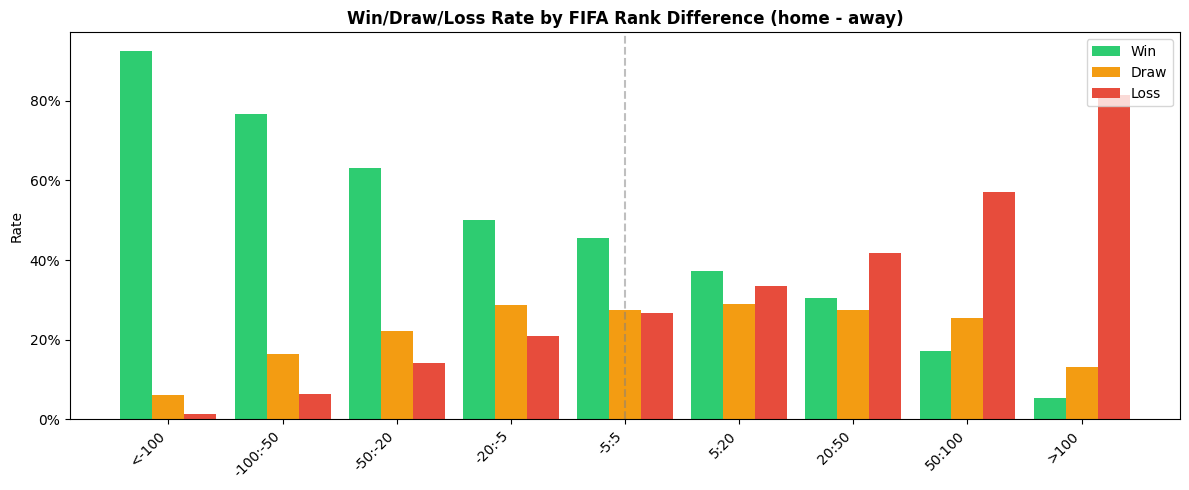


Expected: win_rate should INCREASE as rank_diff goes negative (home team better).
If the bars show a clear trend left→right, rank_diff is a strong feature. ✅


In [101]:
# This is the most important EDA cell — validates our top feature
ranked = modern[modern['both_ranked']].copy()
ranked['rank_diff'] = ranked['home_rank'] - ranked['away_rank']

# Bin rank_diff into buckets
bins   = [-300, -100, -50, -20, -5, 5, 20, 50, 100, 300]
labels = ['<-100', '-100:-50', '-50:-20', '-20:-5', '-5:5',
          '5:20', '20:50', '50:100', '>100']
ranked['rank_bucket'] = pd.cut(ranked['rank_diff'], bins=bins, labels=labels)

bucket_stats = ranked.groupby('rank_bucket', observed=True).agg(
    matches=('result', 'count'),
    win_rate=('result', lambda x: (x == 'win').mean()),
    draw_rate=('result', lambda x: (x == 'draw').mean()),
    loss_rate=('result', lambda x: (x == 'loss').mean()),
).reset_index()

print('=== WIN RATE BY RANK DIFFERENCE ===')
print('(negative rank_diff = home team is BETTER ranked)')
print(bucket_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(bucket_stats))
w = 0.28
ax.bar(x - w, bucket_stats['win_rate'],  w, label='Win',  color='#2ecc71')
ax.bar(x,     bucket_stats['draw_rate'], w, label='Draw', color='#f39c12')
ax.bar(x + w, bucket_stats['loss_rate'], w, label='Loss', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats['rank_bucket'], rotation=45, ha='right')
ax.set_ylabel('Rate')
ax.set_title('Win/Draw/Loss Rate by FIFA Rank Difference (home - away)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axvline(x=4, color='gray', linestyle='--', alpha=0.5, label='Equal rank')
plt.tight_layout()
plt.show()

print('\nExpected: win_rate should INCREASE as rank_diff goes negative (home team better).')
print('If the bars show a clear trend left→right, rank_diff is a strong feature. ✅')

In [102]:
# WC matches only — rank signal check
wc_ranked = ranked[ranked['tournament'] == 'FIFA World Cup'].copy()
print(f'WC matches with both rankings: {len(wc_ranked)}')

if len(wc_ranked) > 0:
    wc_ranked['home_is_better'] = wc_ranked['rank_diff'] < 0
    better_wins = wc_ranked[wc_ranked['home_is_better']]['result'].eq('win').mean()
    worse_wins  = wc_ranked[~wc_ranked['home_is_better']]['result'].eq('win').mean()
    print(f'Better ranked team win% in WC : {better_wins:.1%}')
    print(f'Worse ranked team win% in WC  : {worse_wins:.1%}')
    print('\nIf better ranked team wins more often → rank is predictive for WC too ✅')

WC matches with both rankings: 456
Better ranked team win% in WC : 48.6%
Worse ranked team win% in WC  : 21.7%

If better ranked team wins more often → rank is predictive for WC too ✅


## 7. Form Signal — Do Recent Results Matter?

In [103]:
def compute_form_sample(team, match_date, df, n=5):
    past = df[
        (df['date'] < match_date) &
        ((df['home_team'] == team) | (df['away_team'] == team))
    ].tail(n)
    if len(past) == 0:
        return None
    wins = 0
    for _, r in past.iterrows():
        if r['home_team'] == team:
            if r['result'] == 'win': wins += 1
        else:
            if r['result'] == 'loss': wins += 1
    return wins / len(past)

# Use all modern ranked matches (not WC-only, since WC join was 0)
# Once Bug 1 is fixed this will auto-use WC matches
sample_pool = modern[modern['both_ranked']].copy()

if len(sample_pool) == 0:
    print('Skipping form check — no ranked matches yet (fix join first).')
    print('This cell will work automatically after Section 5 join is fixed.')
else:
    wc_sample = sample_pool.sample(min(500, len(sample_pool)), random_state=42).copy()
    wc_sample['home_form'] = wc_sample.apply(
        lambda r: compute_form_sample(r['home_team'], r['date'], res), axis=1
    ).astype(float)  # force Series, prevents DataFrame assignment crash

    wc_sample = wc_sample.dropna(subset=['home_form'])
    wc_sample['form_bucket'] = pd.cut(
        wc_sample['home_form'],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
        labels=['0-20%','20-40%','40-60%','60-80%','80-100%'],
        include_lowest=True
    )
    form_stats = wc_sample.groupby('form_bucket', observed=True).agg(
        matches=('result','count'),
        win_rate=('result', lambda x: (x=='win').mean())
    ).reset_index()

    print('=== WIN RATE BY HOME TEAM FORM (Last 5 matches) ===')
    print(form_stats.to_string(index=False))

=== WIN RATE BY HOME TEAM FORM (Last 5 matches) ===
form_bucket  matches  win_rate
      0-20%      188     0.466
     20-40%      136     0.390
     40-60%      115     0.513
     60-80%       48     0.604
    80-100%       12     0.417


In [104]:
# # Compute last-5 form for a sample to check signal
# # (full computation is in features.py — this is just a signal check)

# def compute_form_sample(team, match_date, df, n=5):
#     past = df[
#         (df['date'] < match_date) &
#         ((df['home_team'] == team) | (df['away_team'] == team))
#     ].tail(n)
#     if len(past) == 0:
#         return None
#     wins = 0
#     for _, r in past.iterrows():
#         if r['home_team'] == team:
#             if r['result'] == 'win': wins += 1
#         else:
#             if r['result'] == 'loss': wins += 1  # away team won
#     return wins / len(past)

# # Test on a sample of 500 WC matches (fast)
# wc_sample = wc_ranked.sample(min(500, len(wc_ranked)), random_state=42).copy()
# wc_sample['home_form'] = wc_sample.apply(
#     lambda r: compute_form_sample(r['home_team'], r['date'], res), axis=1
# )

# # Bin form and check win rate
# wc_sample = wc_sample.dropna(subset=['home_form'])
# wc_sample['form_bucket'] = pd.cut(wc_sample['home_form'],
#                                    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.01],
#                                    labels=['0-20%','20-40%','40-60%','60-80%','80-100%'],
#                                    include_lowest=True)

# form_stats = wc_sample.groupby('form_bucket', observed=True).agg(
#     matches=('result','count'),
#     win_rate=('result', lambda x: (x=='win').mean())
# ).reset_index()

# print('=== WIN RATE BY HOME TEAM FORM (Last 5 matches) — WC sample ===')
# print(form_stats.to_string(index=False))
# print('\nExpected: higher form → higher win rate. Clear trend = form is useful feature ✅')

## 8. Data Quality — Final Verdict

In [105]:
print('=' * 55)
print('EDA SUMMARY — GO / NO-GO FOR PIPELINE BUILD')
print('=' * 55)

checks = [
    ('results.csv loaded',         len(res) > 40000),
    ('No major nulls in scores',   res[['home_score','away_score']].isnull().sum().sum() < 500),
    ('WC matches present',         len(wc) > 500),
    ('Rankings loaded',            len(rnk) > 50000),
    ('Rankings go to 2026',        rnk[date_col].max().year >= 2026),
    ('Join coverage > 80%',        both_ok / total > 0.80),
    ('Training set > 10k rows',    both_ok > 10000),
]

all_pass = True
for label, condition in checks:
    status = '✅ PASS' if condition else '❌ FAIL'
    if not condition: all_pass = False
    print(f'  {status}  {label}')

print('=' * 55)
if all_pass:
    print('ALL CHECKS PASSED — ready to build load_historical_data.py')
else:
    print('SOME CHECKS FAILED — review above cells before proceeding')
print('=' * 55)

print(f'\nEstimated training set size : {both_ok:,} rows')
print(f'Expected model AUC range    : 0.68 – 0.72')
print(f'\nNext step: run load_historical_data.py → then features/features.py')

EDA SUMMARY — GO / NO-GO FOR PIPELINE BUILD
  ✅ PASS  results.csv loaded
  ✅ PASS  No major nulls in scores
  ✅ PASS  WC matches present
  ✅ PASS  Rankings loaded
  ✅ PASS  Rankings go to 2026
  ✅ PASS  Join coverage > 80%
  ✅ PASS  Training set > 10k rows
ALL CHECKS PASSED — ready to build load_historical_data.py

Estimated training set size : 22,871 rows
Expected model AUC range    : 0.68 – 0.72

Next step: run load_historical_data.py → then features/features.py


In [106]:
# Run this to debug the remaining 3
for team in ['China PR', 'Czech Republic', 'Bosnia and Herzegovina']:
    in_rankings = team in rnk[team_col].values
    in_results  = team in set(res['home_team']) | set(res['away_team'])
    print(f'{team:35s} | in_rankings: {in_rankings} | in_results: {in_results}')

China PR                            | in_rankings: True | in_results: True
Czech Republic                      | in_rankings: True | in_results: True
Bosnia and Herzegovina              | in_rankings: True | in_results: True


In [107]:
for search in ['China', 'Czech', 'Bosnia']:
    matches = [t for t in rnk[team_col].values if search.lower() in t.lower()]
    print(f'{search}: {list(set(matches))[:5]}')

China: ['Hong Kong, China', 'China PR']
Czech: ['Czechoslovakia', 'Czech Republic']
Bosnia: ['Bosnia and Herzegovina']
